# 1. Exploratory Data Analysis — Used Car Price Prediction

Dataset: Vehicle Dataset from CarDekho (Kaggle) — `data/car_data.csv`

This notebook covers:
1. Load & inspect the data
2. Target variable (`Selling_Price`) analysis
3. Correlation analysis
4. Relationship plots
5. Car age analysis
6. Key findings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Load and Inspect

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


**Observation:** The dataset has 301 rows and 9 columns, with **no missing values**.
There are **2 duplicate rows** — these are legitimate near-identical listings (same model/year
re-listed with slightly different mileage in a couple of cases) but true exact duplicates should
be dropped before modeling to avoid data leakage between train/test splits.

## 2. Target Variable Analysis — `Selling_Price`

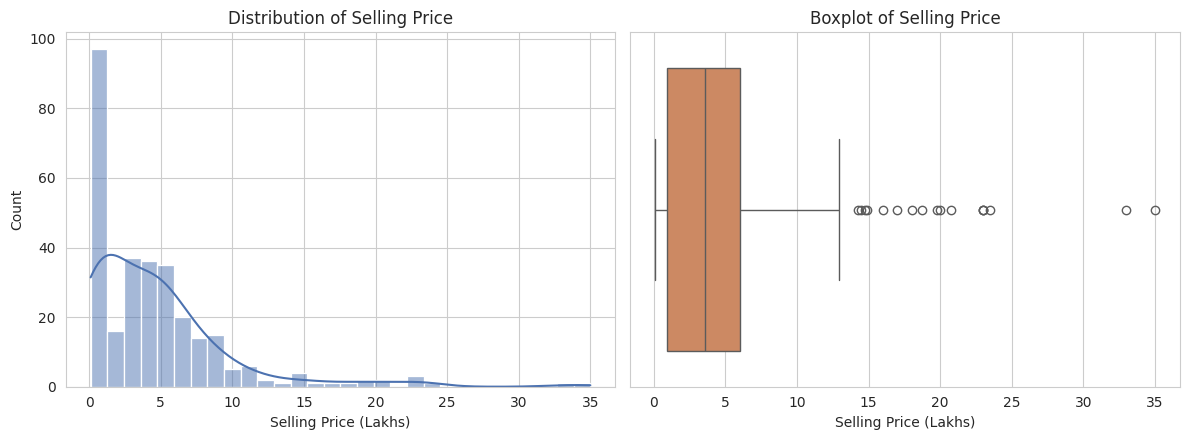

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (Lakhs)')

sns.boxplot(x=df['Selling_Price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot of Selling Price')
axes[1].set_xlabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.savefig('../screenshots/target_distribution.png', dpi=110)
plt.show()

In [5]:
summary = df['Selling_Price'].describe()
print(summary)
print("\nSkewness:", round(df['Selling_Price'].skew(), 3))

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

Skewness: 2.493


**Observation:** `Selling_Price` ranges from 0.10 to 35.0 Lakhs, mean ≈ 4.66, median = 3.60.
Skewness ≈ **2.49**, i.e. strongly **right-skewed** — most cars sell for under 10 Lakhs, with a
long tail of a few premium vehicles (Land Cruiser, Fortuner, Corolla Altis) pulling the mean above
the median. A log-transform of the target (or use of tree-based models that are less sensitive to
skew) is worth considering.

## 3. Correlation Analysis

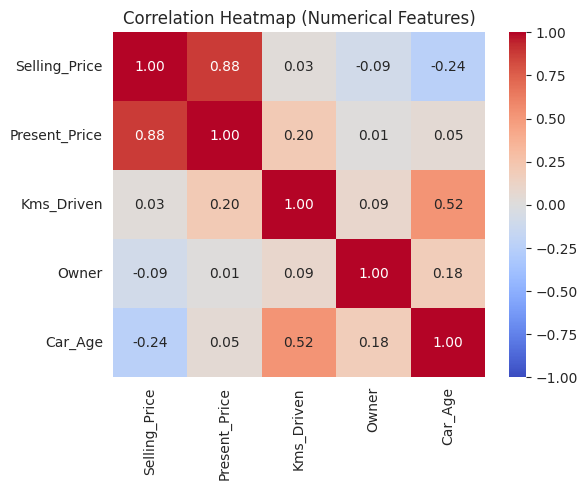

In [6]:
df_corr = df.copy()
df_corr['Car_Age'] = 2018 - df_corr['Year']
num_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']

plt.figure(figsize=(6, 5))
sns.heatmap(df_corr[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=110)
plt.show()

In [7]:
df_corr[num_cols].corr()['Selling_Price'].sort_values(ascending=False)

Selling_Price    1.000000
Present_Price    0.878983
Kms_Driven       0.029187
Owner           -0.088344
Car_Age         -0.236141
Name: Selling_Price, dtype: float64

**Observation:** `Present_Price` correlates most strongly with `Selling_Price` (r ≈ **0.88**) — the
ex-showroom price is the dominant driver of resale value. `Car_Age` has a moderate negative
correlation (r ≈ -0.24): older cars sell for less. `Kms_Driven` and `Owner` have very weak
correlation with price on their own, though they may still interact non-linearly with price
(captured better by tree-based models).

## 4. Relationship Plots

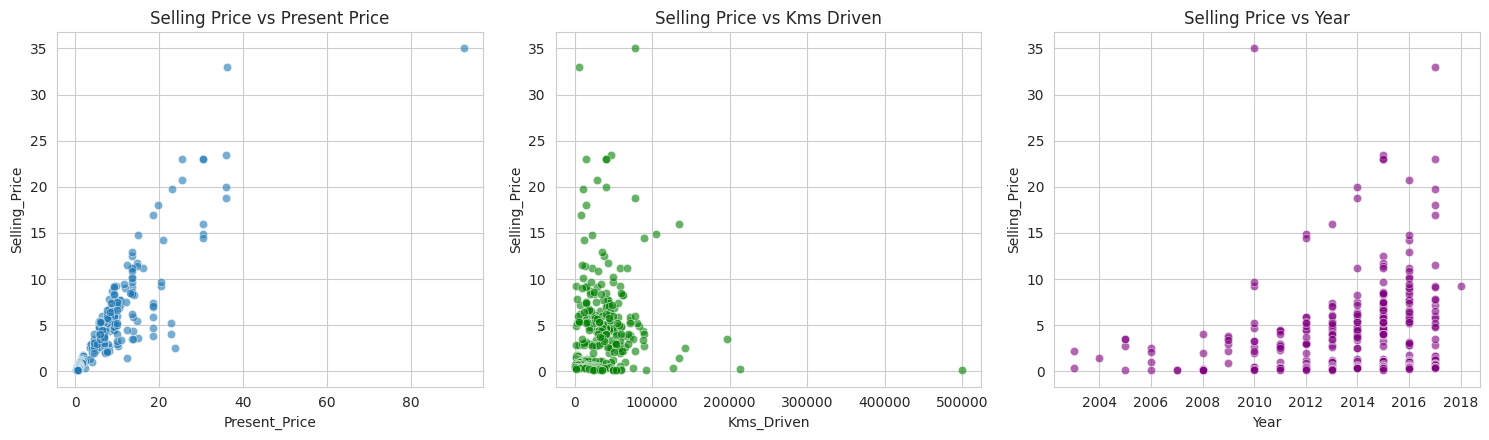

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', ax=axes[0], alpha=0.6)
axes[0].set_title('Selling Price vs Present Price')

sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', ax=axes[1], alpha=0.6, color='green')
axes[1].set_title('Selling Price vs Kms Driven')

sns.scatterplot(data=df, x='Year', y='Selling_Price', ax=axes[2], alpha=0.6, color='purple')
axes[2].set_title('Selling Price vs Year')
plt.tight_layout()
plt.savefig('../screenshots/scatter_relationships.png', dpi=110)
plt.show()

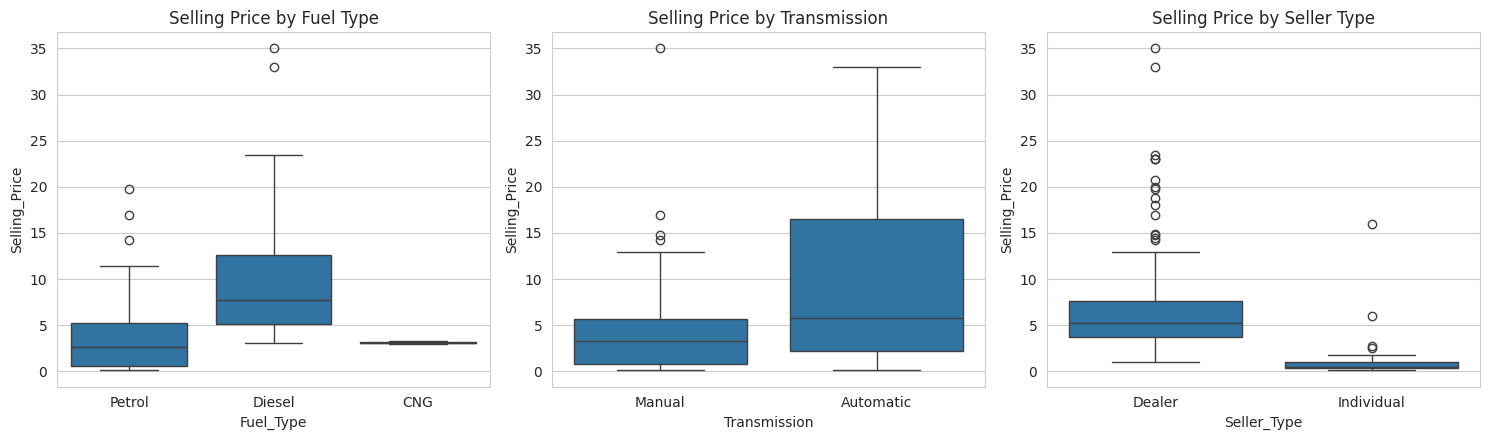

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0])
axes[0].set_title('Selling Price by Fuel Type')

sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[1])
axes[1].set_title('Selling Price by Transmission')

sns.boxplot(data=df, x='Seller_Type', y='Selling_Price', ax=axes[2])
axes[2].set_title('Selling Price by Seller Type')
plt.tight_layout()
plt.savefig('../screenshots/boxplots_categorical.png', dpi=110)
plt.show()

**Observation:**
- `Selling_Price` rises almost linearly with `Present_Price` — confirms the strong correlation above.
- `Kms_Driven` shows a mild downward trend with a few high-mileage outliers (one listing shows
  500,000 km, almost certainly a data-entry error).
- Newer `Year` cars sell for visibly more.
- **Diesel** cars have a higher median selling price than Petrol/CNG (likely driven by larger,
  more expensive vehicles like the Fortuner/Innova being diesel).
- **Automatic** transmission cars sell for noticeably more than manual.
- **Dealer**-sold cars have a higher median price than individual sellers.

## 5. Car Age Analysis

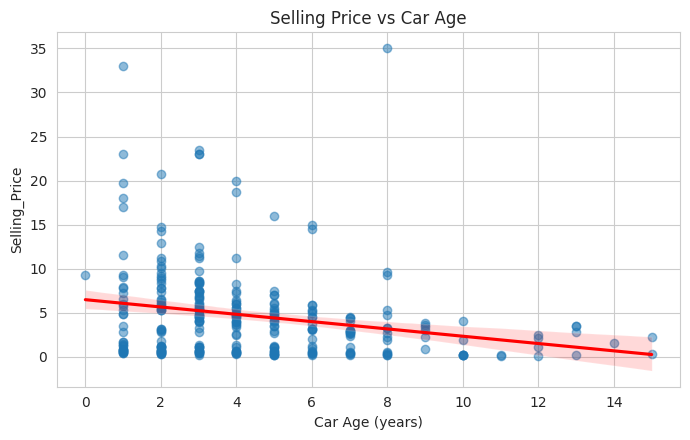

In [10]:
df['Car_Age'] = 2018 - df['Year']

plt.figure(figsize=(7, 4.5))
sns.regplot(data=df, x='Car_Age', y='Selling_Price', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.tight_layout()
plt.savefig('../screenshots/car_age_vs_price.png', dpi=110)
plt.show()

**Observation:** Price generally declines as `Car_Age` increases, though the relationship is
noisy because `Present_Price` (original showroom value) varies enormously across car segments —
a 10-year-old Fortuner still sells for more than a brand-new hatchback. This suggests
`Car_Age` interacts with `Present_Price` rather than acting independently, which favors
tree-based models that can capture such interactions.

## 6. Key Findings

- **`Present_Price` is by far the strongest single predictor** of `Selling_Price` (r ≈ 0.88) —
  it anchors the price scale for every other feature.
- **`Selling_Price` is right-skewed** (skew ≈ 2.49) with a long tail of premium vehicles — tree
  models handle this better than plain linear regression.
- **`Car_Age`** (derived from `Year`) has a clear negative relationship with price and is more
  interpretable than the raw `Year` column, so `Year` is dropped after creating `Car_Age`.
- **`Fuel_Type` = CNG** has only 2 rows — a very low-signal category; one-hot encoding with
  `handle_unknown='ignore'` avoids errors if it's missing from a train split.
- **`Kms_Driven` has an extreme outlier** (500,000 km) that should be capped/clipped before
  training to prevent it from distorting scaled models like Linear/Ridge Regression.
- **`Car_Name`** is high-cardinality (nearly one-per-row after variant names) and is dropped;
  its price signal is already captured by `Present_Price`.
- **Preprocessing plan:** drop `Car_Name`; engineer `Car_Age` and drop `Year`; cap the
  `Kms_Driven` outlier; one-hot encode `Fuel_Type`, `Seller_Type`, `Transmission`; scale numeric
  features only for Linear/Ridge Regression (tree models use the raw values).